In [45]:
import matplotlib.pyplot as plt
import pandas as pd
import pathlib as path

In [46]:
parent_dir = path.Path.cwd().parent
data = pd.read_csv(parent_dir / "data" / "properties_2016_raw.csv",
                   dtype={
                        'hashottuborspa': 'string',
                        'propertycountylandusecode': 'string',
                        'propertyzoningdesc': 'string',
                        'fireplaceflag': 'string',
                        'taxdelinquencyflag': 'string',
                        }
)

In [47]:
print(data.columns)

Index(['parcelid', 'airconditioningtypeid', 'architecturalstyletypeid',
       'basementsqft', 'bathroomcnt', 'bedroomcnt', 'buildingclasstypeid',
       'buildingqualitytypeid', 'calculatedbathnbr', 'decktypeid',
       'finishedfloor1squarefeet', 'calculatedfinishedsquarefeet',
       'finishedsquarefeet12', 'finishedsquarefeet13', 'finishedsquarefeet15',
       'finishedsquarefeet50', 'finishedsquarefeet6', 'fips', 'fireplacecnt',
       'fullbathcnt', 'garagecarcnt', 'garagetotalsqft', 'hashottuborspa',
       'heatingorsystemtypeid', 'latitude', 'longitude', 'lotsizesquarefeet',
       'poolcnt', 'poolsizesum', 'pooltypeid10', 'pooltypeid2', 'pooltypeid7',
       'propertycountylandusecode', 'propertylandusetypeid',
       'propertyzoningdesc', 'rawcensustractandblock', 'regionidcity',
       'regionidcounty', 'regionidneighborhood', 'regionidzip', 'roomcnt',
       'storytypeid', 'threequarterbathnbr', 'typeconstructiontypeid',
       'unitcnt', 'yardbuildingsqft17', 'yardbuildin

In [48]:
cols = ["longitude", "latitude"]
geo_data = data[cols].dropna(how = "any").sort_values(by = ['latitude', 'longitude'])
geo_data.describe()

,longitude,latitude
count,2.973780e+06,2.973780e+06
mean,-1.182019e+08,3.400147e+07
std,3.453171e+05,2.433812e+05
min,-1.194758e+08,3.332439e+07
25%,-1.183930e+08,3.382768e+07
50%,-1.181725e+08,3.400825e+07
75%,-1.179495e+08,3.416186e+07
max,-1.175543e+08,3.481965e+07


In [49]:
max_latitude = 34.33729521663121 * 1e6 // 1
min_latitude = 33.704608786053 * 1e6 // 1
max_longitude = -118.15541491562345 * 1e6 // 1
min_longitude = -118.66813567797944 * 1e6 // 1

In [51]:
data_la_only = data[(data["longitude"] <= max_longitude) & (data["longitude"] >= min_longitude) &
                            (data["latitude"] <= max_latitude) & (data["latitude"] >= min_latitude)]

In [52]:
data_la_only.describe()

,parcelid,airconditioningtypeid,architecturalstyletypeid,basementsqft,bathroomcnt,bedroomcnt,buildingclasstypeid,buildingqualitytypeid,calculatedbathnbr,decktypeid,...,yardbuildingsqft26,yearbuilt,numberofstories,structuretaxvaluedollarcnt,taxvaluedollarcnt,assessmentyear,landtaxvaluedollarcnt,taxamount,taxdelinquencyyear,censustractandblock
count,1.182066e+06,345354.000000,1.0,88.000000,1.182054e+06,1.182059e+06,10217.000000,1.133776e+06,1.150224e+06,196.0,...,59.000000,1.171510e+06,10743.000000,1.166144e+06,1.172236e+06,1.182066e+06,1.172211e+06,1.176706e+06,30771.000000,1.153701e+06
mean,1.175961e+07,1.043561,10.0,544.943182,2.223685e+00,3.046981e+00,3.725066,5.810135e+00,2.285213e+00,66.0,...,326.983051,1.954789e+03,1.116541,1.781558e+05,4.575646e+05,2.014999e+03,2.803406e+05,5.936300e+03,13.902701,6.037489e+13
std,1.892853e+06,0.720663,NaN,419.247996,1.186299e+00,1.379093e+00,0.507260,1.914494e+00,1.142651e+00,0.0,...,432.982619,2.436962e+01,0.370190,5.819098e+05,9.699787e+05,4.140446e-02,5.428224e+05,1.245928e+04,2.604742,3.238051e+10
min,1.071172e+07,1.000000,10.0,80.000000,0.000000e+00,0.000000e+00,1.000000,1.000000e+00,1.000000e+00,66.0,...,27.000000,1.806000e+03,1.000000,1.000000e+00,1.000000e+00,2.002000e+03,1.000000e+00,1.340000e+00,0.000000,6.037101e+13
25%,1.106243e+07,1.000000,10.0,233.250000,1.000000e+00,2.000000e+00,3.000000,4.000000e+00,2.000000e+00,66.0,...,140.000000,1.939000e+03,1.000000,7.055775e+04,1.764658e+05,2.015000e+03,7.796900e+04,2.424680e+03,14.000000,6.037143e+13
50%,1.169665e+07,1.000000,10.0,408.000000,2.000000e+00,3.000000e+00,4.000000,7.000000e+00,2.000000e+00,66.0,...,200.000000,1.953000e+03,1.000000,1.193290e+05,3.011400e+05,2.015000e+03,1.680000e+05,4.033545e+03,14.000000,6.037271e+13
75%,1.222198e+07,1.000000,10.0,729.750000,3.000000e+00,4.000000e+00,4.000000,7.000000e+00,3.000000e+00,66.0,...,372.000000,1.971000e+03,1.000000,1.949820e+05,5.065465e+05,2.015000e+03,3.211000e+05,6.546570e+03,15.000000,6.037554e+13
max,1.631873e+08,13.000000,10.0,2026.000000,2.000000e+01,2.000000e+01,5.000000,1.200000e+01,2.000000e+01,66.0,...,3000.000000,2.015000e+03,5.000000,2.514860e+08,2.827860e+08,2.015000e+03,9.024622e+07,3.458861e+06,99.000000,6.111008e+13


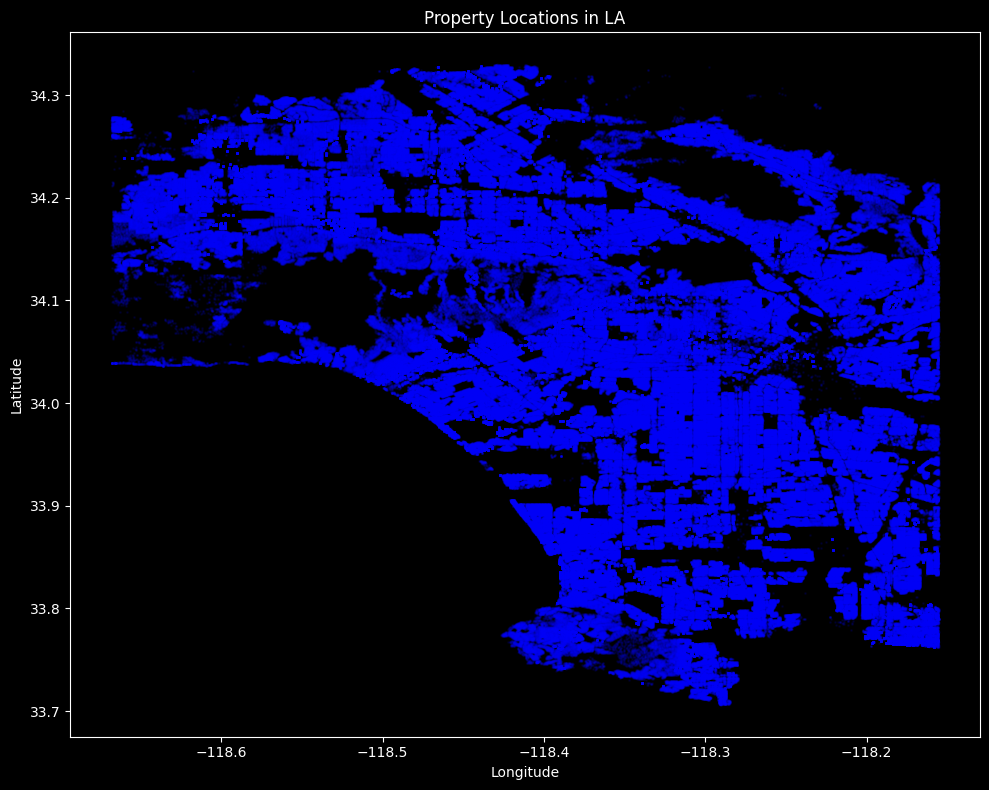

In [53]:
lon = data_la_only['longitude'] / 1e6
lat = data_la_only['latitude'] / 1e6

plt.figure(figsize=(10, 8))

# s=1 makes the dots tiny, alpha=0.1 makes them transparent
plt.scatter(lon, lat, s=1, alpha=0.1, color='blue')

plt.title("Property Locations in LA")
plt.xlabel("Longitude")
plt.ylabel("Latitude")

plt.tight_layout()
plt.show()

In [59]:
cols = ["taxvaluedollarcnt", "taxdelinquencyflag", "taxdelinquencyyear", "latitude", "longitude"]
tax_data = data_la_only[cols].fillna(value={"taxdelinquencyflag": "N", "taxdelinquencyyear": 0}).sort_values(by=['taxvaluedollarcnt', 'taxdelinquencyyear']).reset_index(drop=True)

late = tax_data[tax_data['taxdelinquencyflag'] == 'Y']
punctual = tax_data.drop(index = late.index)

tax_data.describe()
late["taxdelinquencyyear"].sort_values().unique()

array([ 1.,  2.,  3.,  4.,  5.,  6.,  7.,  8.,  9., 10., 11., 12., 13.,
       14., 15., 79., 82., 86., 87., 88., 90., 91., 92., 93., 94., 95.,
       96., 97., 99.])

In [60]:
not_late = tax_data[tax_data['taxdelinquencyflag'] == 'N']
late_1st_group = tax_data[(tax_data['taxdelinquencyyear'] >= 1) & (tax_data['taxdelinquencyyear'] <= 5)]
late_2nd_group = tax_data[(tax_data['taxdelinquencyyear'] >= 6) & (tax_data['taxdelinquencyyear'] <= 10)]
late_3rd_group = tax_data[(tax_data['taxdelinquencyyear'] >= 11) & (tax_data['taxdelinquencyyear'] <= 15)]
late_last_group = tax_data[tax_data['taxdelinquencyyear'] >= 16]

uniq = tax_data["taxdelinquencyyear"].unique()
uniq.sort()
uniq


array([ 0.,  1.,  2.,  3.,  4.,  5.,  6.,  7.,  8.,  9., 10., 11., 12.,
       13., 14., 15., 79., 82., 86., 87., 88., 90., 91., 92., 93., 94.,
       95., 96., 97., 99.])

In [61]:
[not_late.shape[0], late_1st_group.shape[0], late_2nd_group.shape[0], late_3rd_group.shape[0], late_last_group.shape[0]]

[1151296, 31, 1853, 28865, 21]

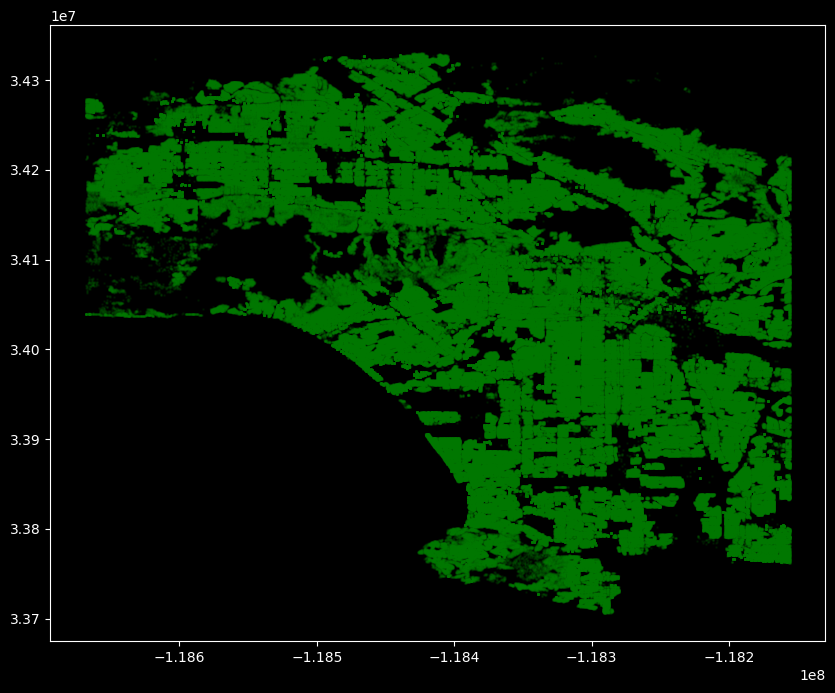

In [68]:
plt.figure(figsize=(10, 8))
plt.scatter(not_late["longitude"], not_late["latitude"], s=1, alpha=0.1, color='green')
plt.show()

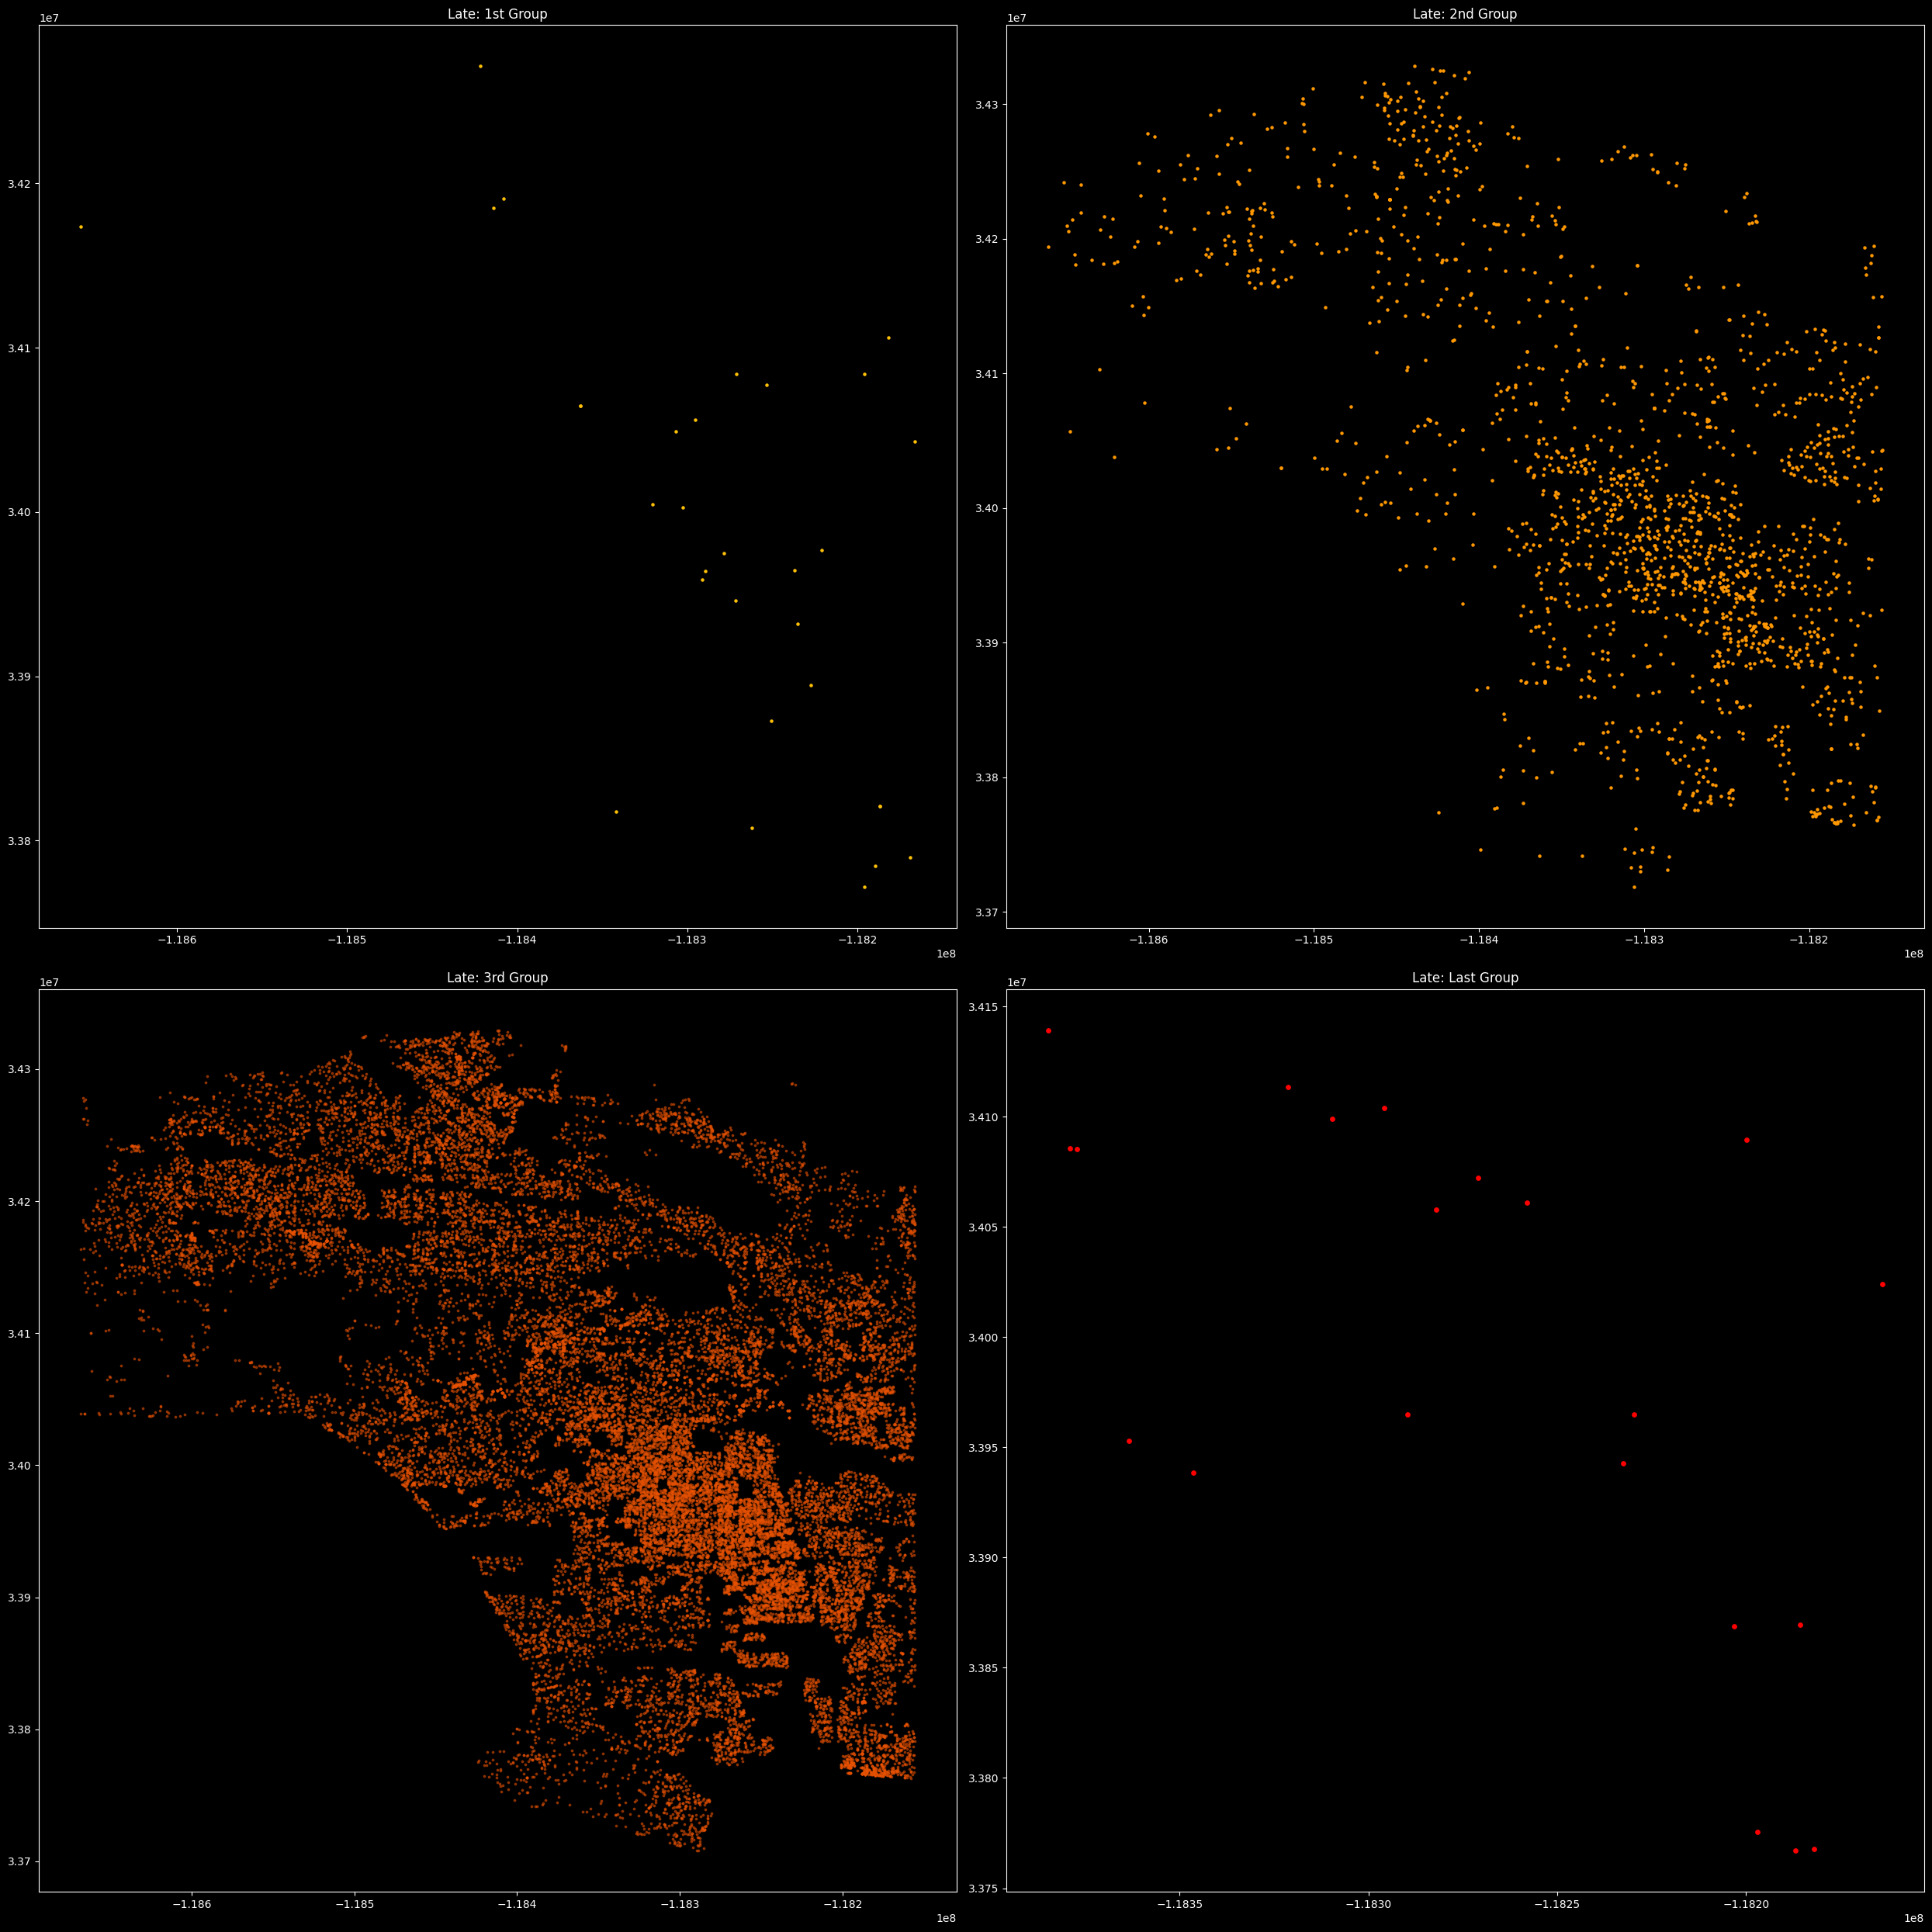

In [65]:
fig, axes = plt.subplots(2, 2, figsize=(25, 25))

axes[0][0].scatter(late_1st_group["longitude"], late_1st_group["latitude"], s=5, alpha=1, color="#FFC107")
axes[0][0].set_title("Late: 1st Group")

axes[0][1].scatter(late_2nd_group["longitude"], late_2nd_group["latitude"], s=5, alpha=1, color="#FF9800")
axes[0][1].set_title("Late: 2nd Group")

axes[1][0].scatter(late_3rd_group["longitude"], late_3rd_group["latitude"], s=3, alpha=0.5, color="#E65100")
axes[1][0].set_title("Late: 3rd Group")

axes[1][1].scatter(late_last_group["longitude"], late_last_group["latitude"], s=15, alpha=1, color="red")
axes[1][1].set_title("Late: Last Group")

plt.tight_layout()

plt.show()

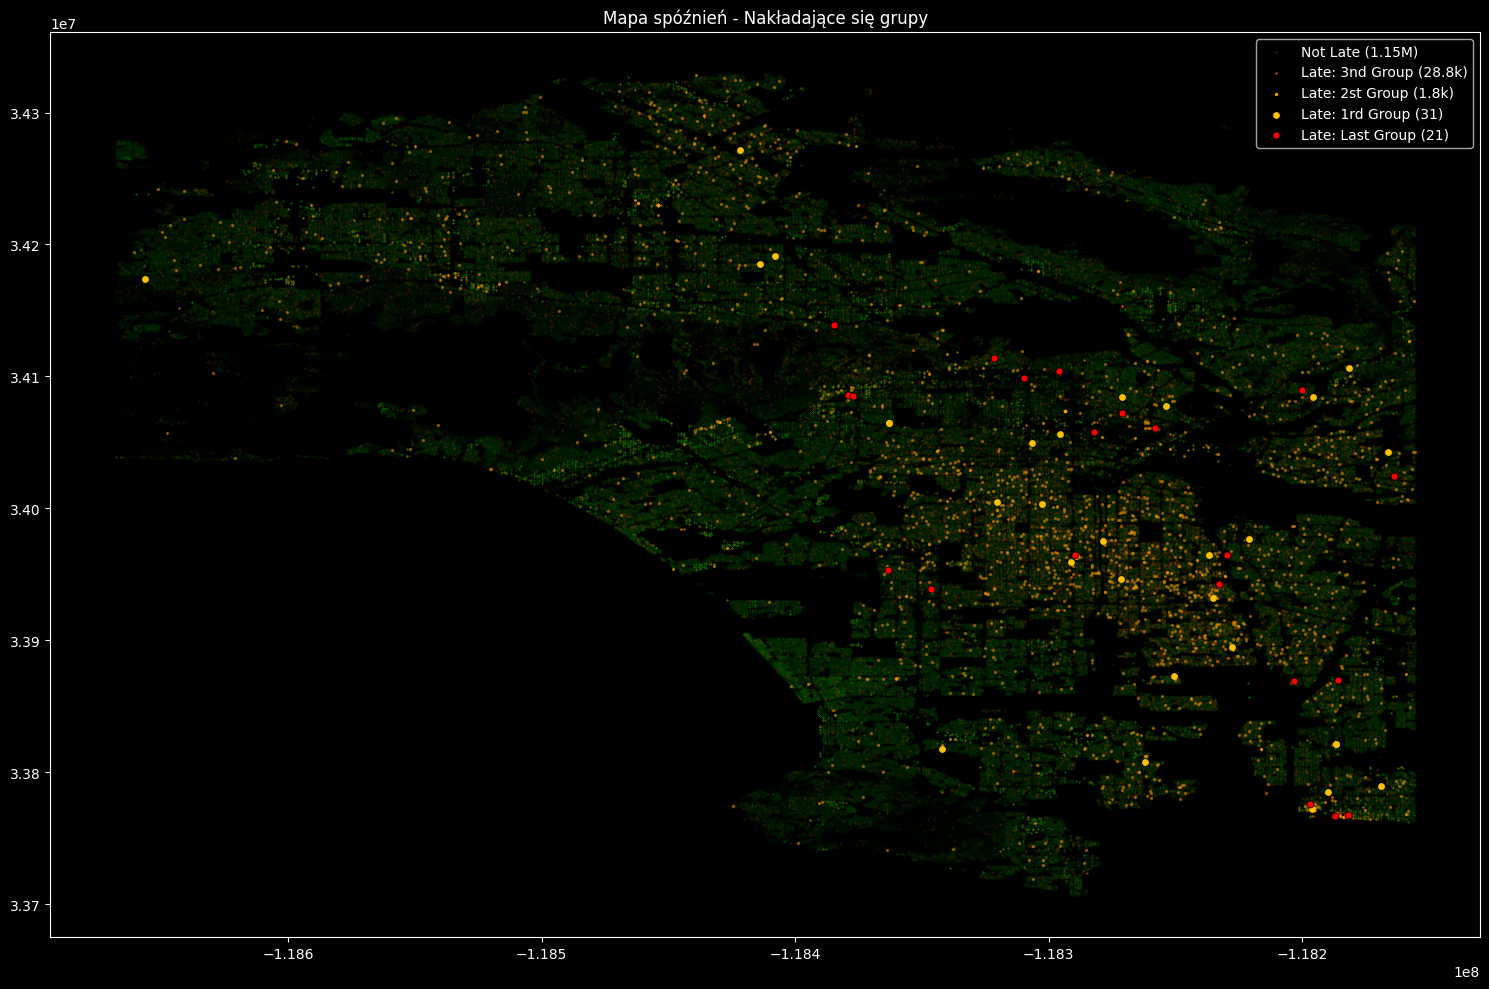

In [92]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(15, 10))

# 1. Największa grupa (1 151 296) - rysujemy na samym dnie
# Bardzo mała kropka i ułamek procenta przezroczystości
ax.scatter(not_late["longitude"], not_late["latitude"],
           s=0.1, alpha=0.05, color='green', label='Not Late (1.15M)')

# 2. Czwarta grupa pod względem wielkości (28 865)
ax.scatter(late_3rd_group["longitude"], late_3rd_group["latitude"],
           s=0.5, alpha=0.1, color='#E65100', label='Late: 3nd Group (28.8k)')

# 3. Trzecia grupa pod względem wielkości (1853)
ax.scatter(late_2nd_group["longitude"], late_2nd_group["latitude"],
           s=2, alpha=0.4, color='#FF9800', label='Late: 2st Group (1.8k)')

# 4. Druga grupa pod względem wielkości (31)
ax.scatter(late_1st_group["longitude"], late_1st_group["latitude"],
           s=15, alpha=1.0, color='#FFC107', label='Late: 1rd Group (31)')

# 5. Najmniejsza grupa (21) - rysujemy na samym wierzchu
ax.scatter(late_last_group["longitude"], late_last_group["latitude"],
           s=25, alpha=1.0, color='red', edgecolors='black', linewidth=0.5, label='Late: Last Group (21)')

# Dodajemy legendę, żeby ułatwić identyfikację
leg = plt.legend(markerscale=1) # Powiększamy kropki w samej legendzie, żeby były widoczne
for lh in leg.legend_handles:
    lh.set_alpha(1) # Wymuszamy brak przezroczystości w legendzie

plt.title("Mapa spóźnień - Nakładające się grupy")
plt.tight_layout()

plt.savefig(file_path, dpi=300, bbox_inches='tight')

plt.show()
